In [ ]:
from google.colab import files
uploaded = files.upload()


Saving SC24H_YEARLY_RISK_VALUES.csv to SC24H_YEARLY_RISK_VALUES.csv


In [ ]:
import pandas as pd

# Assuming the file name is 'SC24H_YEARLY_RISK_VALUES.csv' and it's in the current directory
file_name = 'SC24H_YEARLY_RISK_VALUES.csv'
data = pd.read_csv(file_name)

# Display the first few rows of the DataFrame to verify it's loaded correctly
print(data.head())


     ADM2_EN  2023_10K  Median  Binary  RISK_2023  RISK23EQ
0   Bagerhat    0.8884  1.0548       0     0.3681    0.3730
1  Bandarban    1.1298  1.0548       1     0.3274    0.6218
2    Barguna    3.7975  1.0548       1     0.4246    0.5597
3    Barisal    4.4166  1.0548       1     0.2508    0.3701
4      Bhola    1.6647  1.0548       1     0.3253    0.5934


RISK_2023 AUC: 0.75
RISK23EQ AUC: 0.55


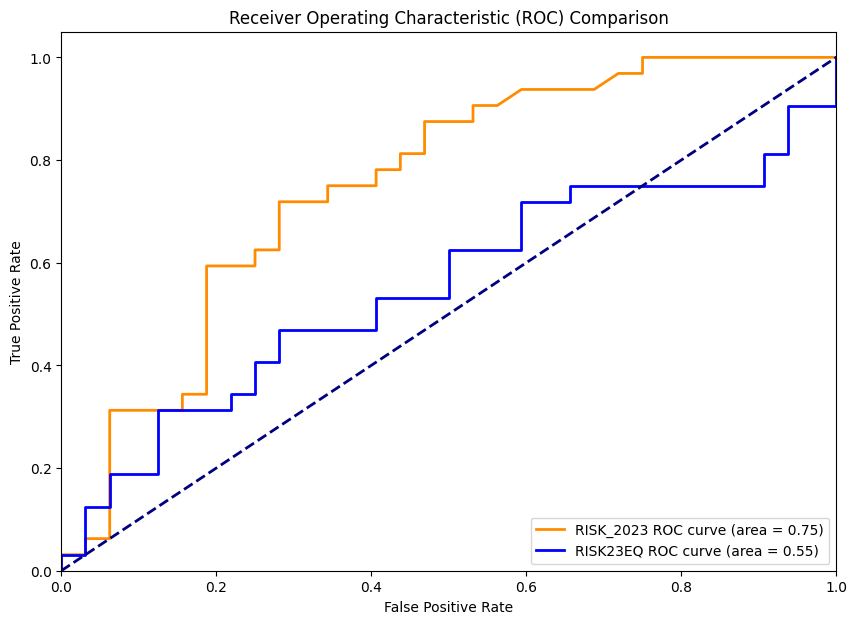

In [ ]:
import pandas as pd
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Separate the actual binary outcomes and the risk values
y_true = data['Binary']
risk_2023_scores = data['RISK_2023']
risk23eq_scores = data['RISK23EQ']

# Compute ROC curve and ROC area for each model
fpr_2023, tpr_2023, _ = roc_curve(y_true, risk_2023_scores)
roc_auc_2023 = auc(fpr_2023, tpr_2023)

fpr_23eq, tpr_23eq, _ = roc_curve(y_true, risk23eq_scores)
roc_auc_23eq = auc(fpr_23eq, tpr_23eq)

# Print AUC values
print(f'RISK_2023 AUC: {roc_auc_2023:.2f}')
print(f'RISK23EQ AUC: {roc_auc_23eq:.2f}')

# Plotting the ROC curves
plt.figure(figsize=(10, 7))
lw = 2
plt.plot(fpr_2023, tpr_2023, color='darkorange',
         lw=lw, label=f'RISK_2023 ROC curve (area = {roc_auc_2023:.2f})')
plt.plot(fpr_23eq, tpr_23eq, color='blue',
         lw=lw, label=f'RISK23EQ ROC curve (area = {roc_auc_23eq:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Comparison')
plt.legend(loc="lower right")
plt.show()
